In [7]:
import re
import random
import string
from pathlib import Path

# ===== Specify the conf file paths here =====
CONF_PATHS = [
    "cu_gnb.conf",            # Previous cu_gnb
    "du_gnb.conf",            # Previous du_gnb
]
OUTPUT_DIR = "./incorrect_confs"  # Output directory for modified conf files
NUM_CHANGES = 2                   # Number of random modifications per conf file

# ===== Utility Functions =====
def rand_string(n=10):
    """Generate a random string"""
    return "".join(random.choice(string.ascii_lowercase) for _ in range(n))

def mutate_value(val: str) -> str:
    """Generate an incorrect value based on the type of input"""
    if re.match(r'^".*"$', val) or re.match(r"^'.*'$", val):
        return f"\"{rand_string(random.randint(6,12))}\""
    if re.match(r"^0x[0-9a-fA-F]+$", val):  # Hexadecimal
        return "0xDEADBEEF"
    if re.match(r"^-?\d+$", val):  # Integer
        return str(random.choice([99999, -1, -123456]))
    if re.match(r'^\(.*\)$', val):  # Tuple or list
        return '( "nia5","nea9" )'
    return f"\"{rand_string()}\""   # Default: random string

def random_modify_conf(input_path: str, output_path: str = None, num_changes: int = 1):
    """Randomly modify parameter values in a conf file"""
    lines = Path(input_path).read_text(encoding="utf-8").splitlines()

    # Find candidate lines (contain "=" and end with ";")
    candidates = [i for i, line in enumerate(lines) if "=" in line and line.strip().endswith(";")]
    if not candidates:
        print(f"⚠️ No modifiable parameter lines found in {input_path}")
        return

    chosen_idxs = random.sample(candidates, min(num_changes, len(candidates)))

    for idx in chosen_idxs:
        original = lines[idx]
        m = re.match(r"^\s*([A-Za-z0-9_]+)\s*=\s*(.*?);\s*$", original)
        if not m:
            continue
        key, value = m.group(1), m.group(2).strip()
        new_value = mutate_value(value)
        new_line = f"{key} = {new_value};"
        print("=== Original line chosen ===")
        print(original)
        print("=== Modified line ===")
        print(new_line, "\n")
        lines[idx] = new_line

    # Write modified file
    if output_path:
        Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
        Path(output_path).write_text("\n".join(lines), encoding="utf-8")
        print(f"✅ Modified file saved to {output_path}")

# ===== Main =====
if __name__ == "__main__":
    for conf in CONF_PATHS:
        path = Path(conf)
        if not path.exists():
            print(f"⚠️ File {conf} not found, skipping")
            continue
        out_path = Path(OUTPUT_DIR) / f"{path.stem}_incorrect.conf"
        print(f"\nProcessing file: {conf}")
        random_modify_conf(str(path), str(out_path), NUM_CHANGES)



Processing file: cu_gnb.conf
=== Original line chosen ===
    local_s_if_name = "lo";
=== Modified line ===
local_s_if_name = "onumiewgeje"; 

=== Original line chosen ===
        GNB_IPV4_ADDRESS_FOR_NG_AMF              = "192.168.8.43";
=== Modified line ===
GNB_IPV4_ADDRESS_FOR_NG_AMF = "gtagjwup"; 

✅ Modified file saved to incorrect_confs\cu_gnb_incorrect.conf

Processing file: du_gnb.conf
=== Original line chosen ===
      dl_absoluteFrequencyPointA                                       = 640008;
=== Modified line ===
dl_absoluteFrequencyPointA = -1; 

=== Original line chosen ===
      referenceSubcarrierSpacing                                    = 1;
=== Modified line ===
referenceSubcarrierSpacing = -123456; 

✅ Modified file saved to incorrect_confs\du_gnb_incorrect.conf


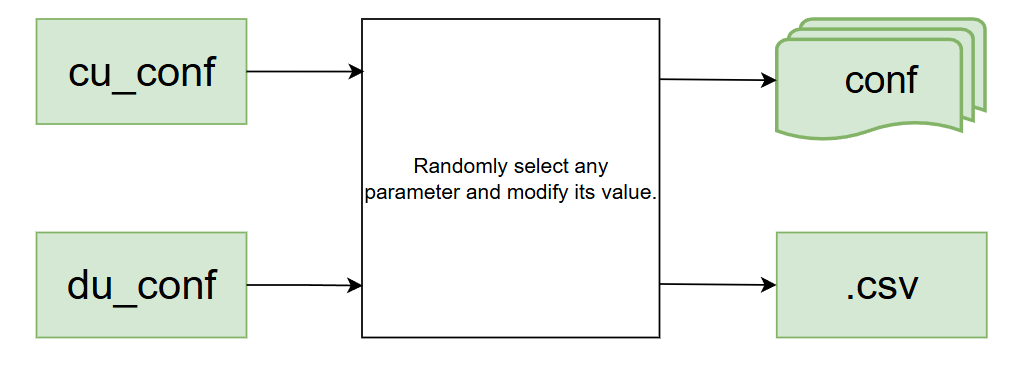

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Per-parameter testing: for every `key = value;` line in the conf, produce a variant file
that modifies ONLY that line, and export an Excel/CSV report (original / modified / key / output file).
"""

import re
import random
import string
from pathlib import Path

# For Excel/CSV export
import pandas as pd

# ===== Paths =====
CONF_PATHS = [
    "cu_gnb.conf",  # Run per-parameter testing on this file
]
OUTPUT_DIR = "./incorrect_confs"   # Output directory

# ===== Utility functions =====
def rand_string(n=10):
    """Generate a random lowercase string"""
    return "".join(random.choice(string.ascii_lowercase) for _ in range(n))

def mutate_value(val: str) -> str:
    """
    Generate an intentionally 'incorrect' value based on the detected value type.
    """
    val = val.strip()

    # Quoted string
    if re.match(r'^".*"$', val) or re.match(r"^'.*'$", val):
        return f"\"{rand_string(random.randint(6,12))}\""

    # IPv4 in ({ ipv4 = "x.x.x.x" })
    if re.match(r'^\(\{\s*ipv4\s*=\s*".*"\s*\}\)$', val):
        octets = [str(random.randint(200,250)) for _ in range(4)]
        return f'({{ ipv4 = "{ ".".join(octets) }" }})'

    # Hexadecimal
    if re.match(r"^0x[0-9a-fA-F]+$", val):
        return "0xDEADBEEF"

    # Integer
    if re.match(r"^-?\d+$", val):
        return str(random.choice([99999, -1, -123456, 1234567]))

    # Tuple or list (e.g., algorithms)
    if re.match(r'^\(.*\)$', val):
        return '( "nia5","nea9" )'

    # Fallback → random string
    return f"\"{rand_string()}\""

def is_candidate_line(line: str) -> bool:
    """
    Candidate line: must match `key = value;` (allow trailing inline comment; we drop it on write).
    """
    s = line.strip()
    if not s or s.startswith("#"):
        return False
    return bool(re.match(r"^\s*[A-Za-z0-9_]+\s*=\s*.*;\s*(#.*)?$", s))

def parse_kv(line: str):
    """
    Parse a single `key = value;` line. Ignore trailing comments.
    Return (indent, key, value, semi).
    """
    m = re.match(r"^(\s*)([A-Za-z0-9_]+)\s*=\s*(.*?)(;)", line)
    if not m:
        return None
    indent, key, value, semi = m.group(1), m.group(2), m.group(3), m.group(4)
    return indent, key, value, semi

def modify_each_param_separately(input_path: str):
    """
    For each candidate param line, produce a variant file with ONLY that line modified,
    and build an Excel/CSV report.
    """
    text = Path(input_path).read_text(encoding="utf-8")
    lines = text.splitlines(keepends=True)

    # Collect candidate lines
    candidates = [i for i, line in enumerate(lines) if is_candidate_line(line)]
    if not candidates:
        print(f"⚠️ No candidate lines found in {input_path}")
        return

    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    successes, failures = [], []
    report_rows = []  # Excel/CSV rows
    width = len(str(len(candidates)))

    for seq, idx in enumerate(candidates, start=1):
        original_line = lines[idx]
        parsed = parse_kv(original_line)
        if not parsed:
            failures.append((idx, original_line.strip(), "parse-failed"))
            continue

        indent, key, value, semi = parsed
        new_value = mutate_value(value)
        new_line = f"{indent}{key} = {new_value}{semi}\n"  # drop inline comment

        if new_line.strip() == original_line.strip():
            failures.append((idx, original_line.strip(), "no-change"))
            continue

        # Replace that line, keep others identical
        new_lines = lines.copy()
        new_lines[idx] = new_line

        # Output filename
        safe_key = re.sub(r'[^A-Za-z0-9_]+', '_', key)[:40]
        out_path = out_dir / f"{Path(input_path).stem}_param_{str(seq).zfill(width)}_{safe_key}_incorrect.conf"
        out_path.write_text("".join(new_lines), encoding="utf-8")

        print(f"[OK] ({seq}/{len(candidates)}) {key}")
        print("  Original:", original_line.rstrip())
        print("  Modified:", new_line.rstrip())

        successes.append((idx, key, out_path.name))
        report_rows.append({
            "Key": key,
            "Original": original_line.strip(),
            "Modified": new_line.strip(),
            "Output File": out_path.name,
        })

    # Summary
    print("\n==== Done ====")
    print(f"Total candidates: {len(candidates)}")
    print(f"Modified successfully: {len(successes)}")
    print(f"Failed: {len(failures)}")
    if failures:
        print("\nFailures:")
        for idx, line, reason in failures:
            print(f"- Line {idx+1}: {reason} | {line}")

    # Export report
    if report_rows:
        df = pd.DataFrame(report_rows, columns=["Key", "Original", "Modified", "Output File"])
        base = Path(input_path).stem
        xlsx_path = out_dir / f"{base}_mod_report.xlsx"
        csv_path  = out_dir / f"{base}_mod_report.csv"
        df.to_excel(xlsx_path, index=False)
        df.to_csv(csv_path, index=False, encoding="utf-8-sig")
        print(f"\n🧾 Reports saved:\n- {xlsx_path}\n- {csv_path}")

# ===== Entry point =====
if __name__ == "__main__":
    for conf in CONF_PATHS:
        path = Path(conf)
        if not path.exists():
            print(f"⚠️ File not found: {conf}")
            continue
        print(f"\n[Per-parameter test] File: {conf}")
        modify_each_param_separately(str(path))



[Per-parameter test] File: cu_gnb.conf
[OK] (1/37) Asn1_verbosity
  Original: Asn1_verbosity = "none";
  Modified: Asn1_verbosity = "zlkvrivj";
[OK] (2/37) Num_Threads_PUSCH
  Original: Num_Threads_PUSCH = 8;
  Modified: Num_Threads_PUSCH = 1234567;
[OK] (3/37) gNB_ID
  Original:     gNB_ID = 0xe00;
  Modified:     gNB_ID = 0xDEADBEEF;
[OK] (4/37) gNB_name
  Original:     gNB_name  =  "gNB-Eurecom-CU";
  Modified:     gNB_name = "gxqnlbwagc";
[OK] (5/37) tracking_area_code
  Original:     tracking_area_code  =  1;
  Modified:     tracking_area_code = 1234567;
[OK] (6/37) mcc
  Original:                 mcc = 001;
  Modified:                 mcc = 1234567;
[OK] (7/37) mnc
  Original:                 mnc = 01;
  Modified:                 mnc = -1;
[OK] (8/37) mnc_length
  Original:                 mnc_length = 2;
  Modified:                 mnc_length = -1;
[OK] (9/37) sst
  Original:                   sst = 1;
  Modified:                   sst = 1234567;
[OK] (10/37) nr_cellid
  Origin

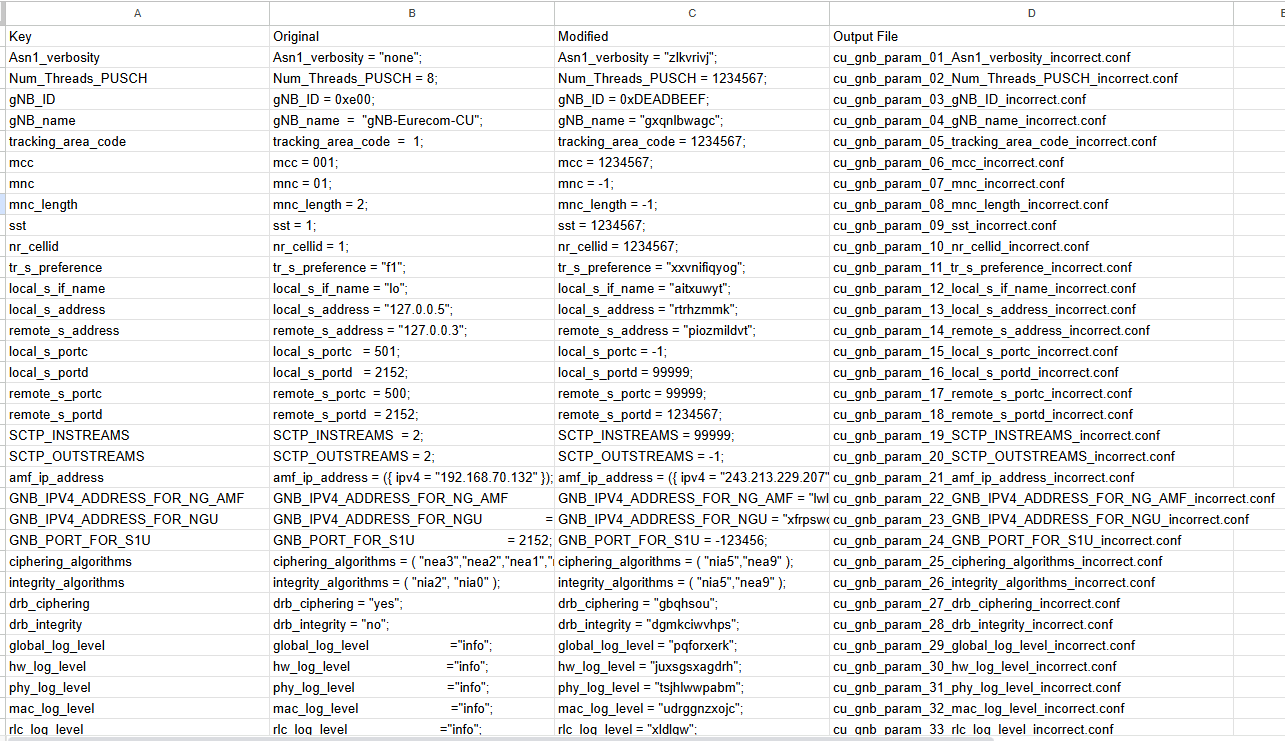